# Análisis Exploratorio de Datos (EDA) - CICIoT2023

Este notebook realiza el análisis exploratorio de datos (EDA) para el dataset consolidado de la tesis:
**"Detección de ataques minoritarios en redes IoT mediante un modelo híbrido basado en Stacking, XGBoost y LightGBM, Puno 2026"**.

### Objetivos del EDA:
1. Obtener estadísticas descriptivas de las columnas numéricas.
2. Analizar la distribución de la variable objetivo (`Label`).
3. Evaluar la matriz de correlación de las top 15 características más relevantes.
4. Detectar la presencia de outliers mediante diagramas de caja (boxplots).
5. Analizar la forma de las distribuciones de las características clave mediante histogramas.
6. Guardar todos los gráficos generados en `results/figures/` para utilizarlos en el informe final de tesis.

In [12]:
import os

# Cambiar el directorio de trabajo a la raíz del proyecto si el notebook se ejecuta desde 'notebooks'
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f"Directorio de trabajo activo: {os.getcwd()}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo visual premium para los gráficos de la tesis
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Crear directorios para los resultados gráficos si no existen
os.makedirs("results/figures", exist_ok=True)
print("Entorno inicializado y carpeta 'results/figures/' lista.")

Directorio de trabajo activo: /home/carmen/tesis_iot
Entorno inicializado y carpeta 'results/figures/' lista.


In [13]:
# Cargar o consolidar el dataset si no existe
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

df_path = "data/processed/dataset_consolidado.csv"

if not os.path.exists(df_path):
    print("El dataset consolidado no existe en data/processed/. Iniciando consolidación de 63 archivos raw...")
    raw_dir = "data/raw"
    processed_dir = "data/processed"
    os.makedirs(processed_dir, exist_ok=True)
    
    files = sorted([f for f in os.listdir(raw_dir) if f.endswith(".csv")])
    samples_per_class_per_file = 2000
    seed = 42
    np.random.seed(seed)
    
    chunks = []
    for f in tqdm(files, desc="Procesando archivos"):
        file_path = os.path.join(raw_dir, f)
        df_temp = pd.read_csv(file_path)
        sampled_dfs = []
        for label, group in df_temp.groupby('Label'):
            if len(group) > samples_per_class_per_file:
                sampled_group = group.sample(n=samples_per_class_per_file, random_state=seed)
                sampled_dfs.append(sampled_group)
            else:
                sampled_dfs.append(group)
        if sampled_dfs:
            chunks.append(pd.concat(sampled_dfs, axis=0))
            
    print("Concatenando todos los fragmentos...")
    df_final = pd.concat(chunks, axis=0, ignore_index=True)
    print(f"Guardando dataset consolidado en: {df_path}...")
    df_final.to_csv(df_path, index=False)
    print("¡Consolidación completada y guardada con éxito!")

print("Cargando dataset consolidado...")
df = pd.read_csv(df_path)
print(f"¡Cargado con éxito! Dimensiones: {df.shape[0]:,} filas, {df.shape[1]} columnas.")

El dataset consolidado no existe en data/processed/. Iniciando consolidación de 63 archivos raw...










Exception ignored in: <function tqdm.__del__ at 0x77aac9e32710>
Traceback (most recent call last):
  File "/home/carmen/miniconda3/envs/tesis_iot/lib/python3.10/site-packages/tqdm/std.py", line 1154, in __del__
    self.close()
  File "/home/carmen/miniconda3/envs/tesis_iot/lib/python3.10/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
























































Procesando archivos: 100%|██████████| 63/63 [01:44<00:00,  1.67s/it]


Concatenando todos los fragmentos...
Guardando dataset consolidado en: data/processed/dataset_consolidado.csv...
¡Consolidación completada y guardada con éxito!
Cargando dataset consolidado...
¡Cargado con éxito! Dimensiones: 2,954,555 filas, 40 columnas.


## 1. Estadísticas Descriptivas

In [14]:
# Generar estadísticas descriptivas para las columnas numéricas
print("Generando estadísticas descriptivas...")
stats = df.describe().transpose()

# Guardar tabla de estadísticas descriptivas en resultados
stats.to_csv("results/eda_estadisticas_descriptivas.csv")
print("Estadísticas guardadas en 'results/eda_estadisticas_descriptivas.csv'")

# Mostrar las primeras 10 características
stats.head(10)

Generando estadísticas descriptivas...


/home/carmen/miniconda3/envs/tesis_iot/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Estadísticas guardadas en 'results/eda_estadisticas_descriptivas.csv'


,count,mean,std,min,25%,50%,75%,max
Header_Length,2954555.0,15.654115,10.429372,0.000000,8.000000,20.000000,20.200000,60.0
Protocol Type,2954555.0,11.431931,11.855539,0.000000,6.000000,6.000000,17.000000,47.0
Time_To_Live,2954555.0,74.578394,28.883735,0.000000,64.000000,64.000000,67.180000,255.0
Rate,2954555.0,inf,NaN,0.000021,857.485383,5632.811367,24813.962019,inf
fin_flag_number,2954555.0,0.050236,0.202715,0.000000,0.000000,0.000000,0.000000,1.0
syn_flag_number,2954555.0,0.164400,0.342904,0.000000,0.000000,0.000000,0.080000,1.0
rst_flag_number,2954555.0,0.071824,0.231992,0.000000,0.000000,0.000000,0.000000,1.0
psh_flag_number,2954555.0,0.096320,0.224868,0.000000,0.000000,0.000000,0.100000,1.0
ack_flag_number,2954555.0,0.274567,0.379975,0.000000,0.000000,0.010000,0.600000,1.0
ece_flag_number,2954555.0,0.000137,0.004982,0.000000,0.000000,0.000000,0.000000,1.0


## 2. Distribución de la Variable Objetivo (Label)

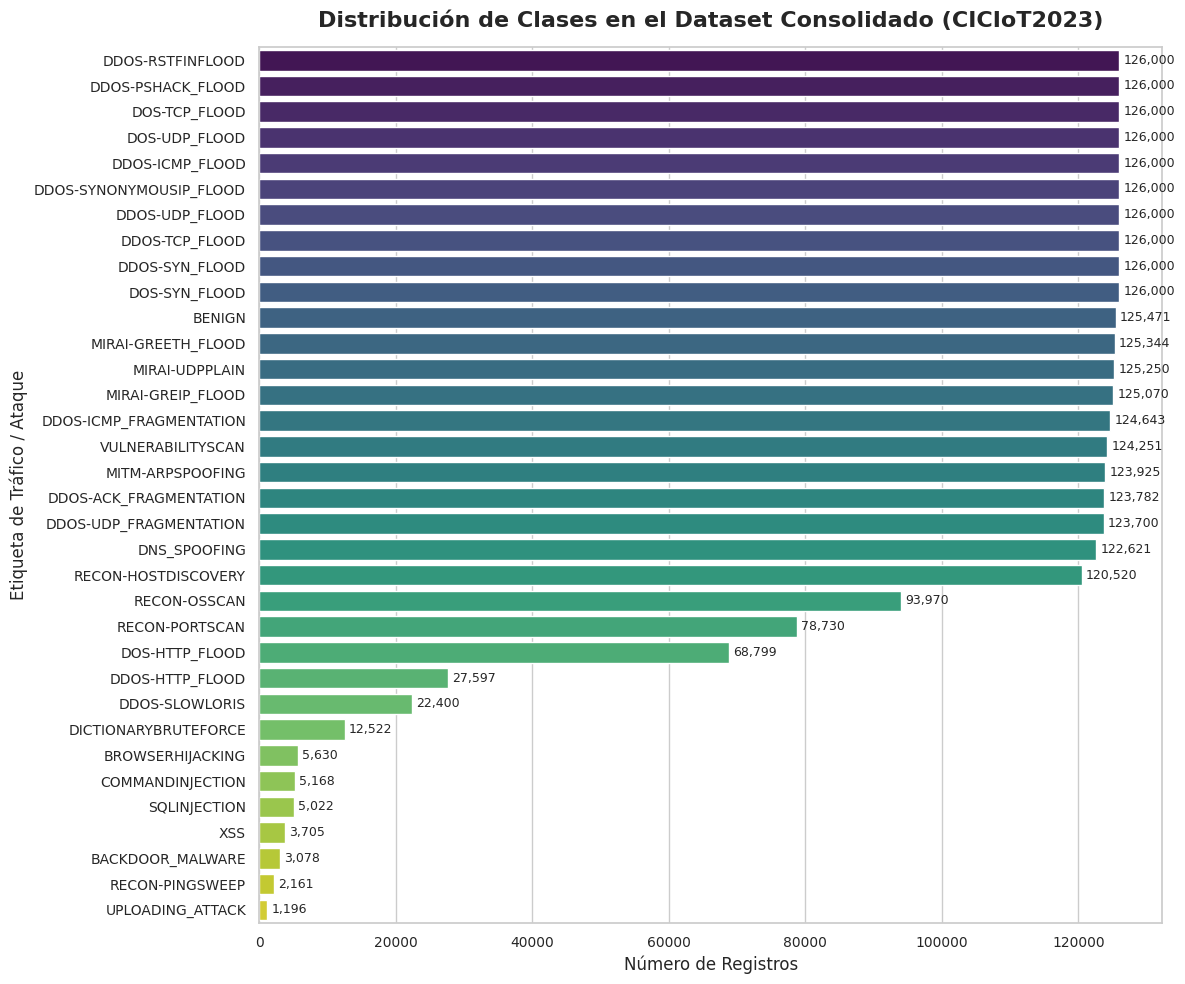

In [16]:
# Obtener conteos de cada clase de ataque
class_counts = df['Label'].value_counts()

# Crear gráfico de barras horizontal
plt.figure(figsize=(12, 10))
colors = sns.color_palette("viridis", len(class_counts))
sns.barplot(y=class_counts.index, x=class_counts.values, palette=colors, hue=class_counts.index, legend=False)

plt.title("Distribución de Clases en el Dataset Consolidado (CICIoT2023)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Número de Registros", fontsize=12)
plt.ylabel("Etiqueta de Tráfico / Ataque", fontsize=12)

# Añadir etiquetas de conteo al final de cada barra
for index, value in enumerate(class_counts.values):
    plt.text(value + (max(class_counts.values)*0.005), index, f"{value:,}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig("results/figures/01_distribucion_clases.png", dpi=300)
plt.show()

## 3. Matriz de Correlación de Características Clave (Top 15)

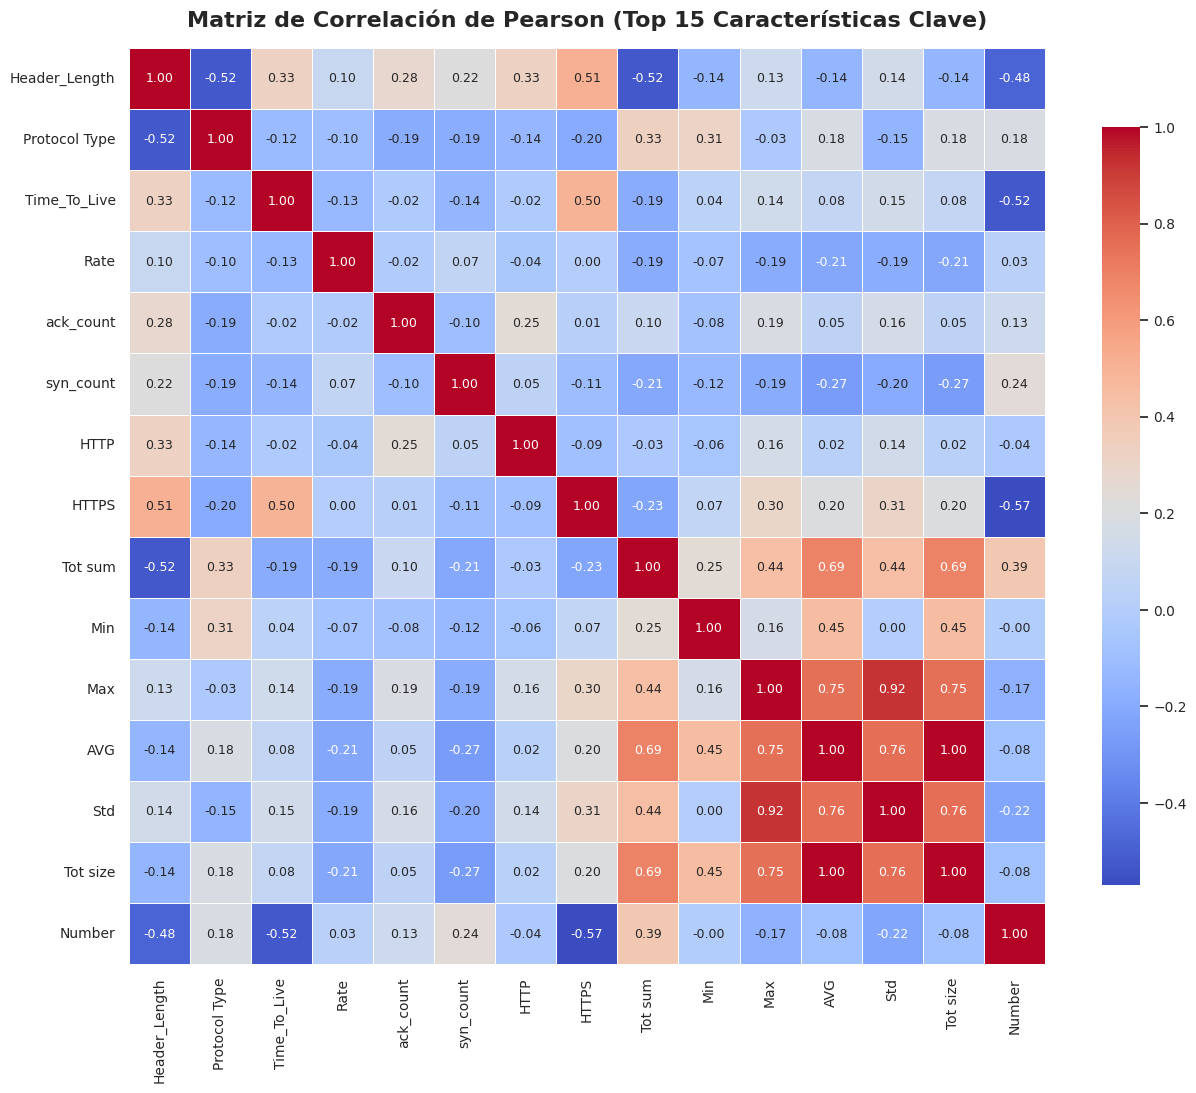

In [5]:
# Para correlación, reemplazamos infinitos por NaN y rellenamos nulos con 0 para cálculos limpios
numeric_cols = df.select_dtypes(include=[np.number]).columns
df_numeric = df[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

# Definimos las 15 características más relevantes en tráfico de red e IoT
features_interes = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'ack_count', 
    'syn_count', 'HTTP', 'HTTPS', 'Tot sum', 'Min', 'Max', 'AVG', 
    'Std', 'Tot size', 'Number'
]

# Filtrar solo las características que existan en el dataset
selected_features = [f for f in features_interes if f in df_numeric.columns]

# Calcular matriz de correlación
corr_matrix = df_numeric[selected_features].corr()

# Dibujar el mapa de calor
plt.figure(figsize=(13, 11))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, square=True, 
            cbar_kws={"shrink": .8}, annot_kws={"size": 9})

plt.title("Matriz de Correlación de Pearson (Top 15 Características Clave)", fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("results/figures/02_matriz_correlacion.png", dpi=300)
plt.show()

## 4. Detección de Outliers (Boxplots)

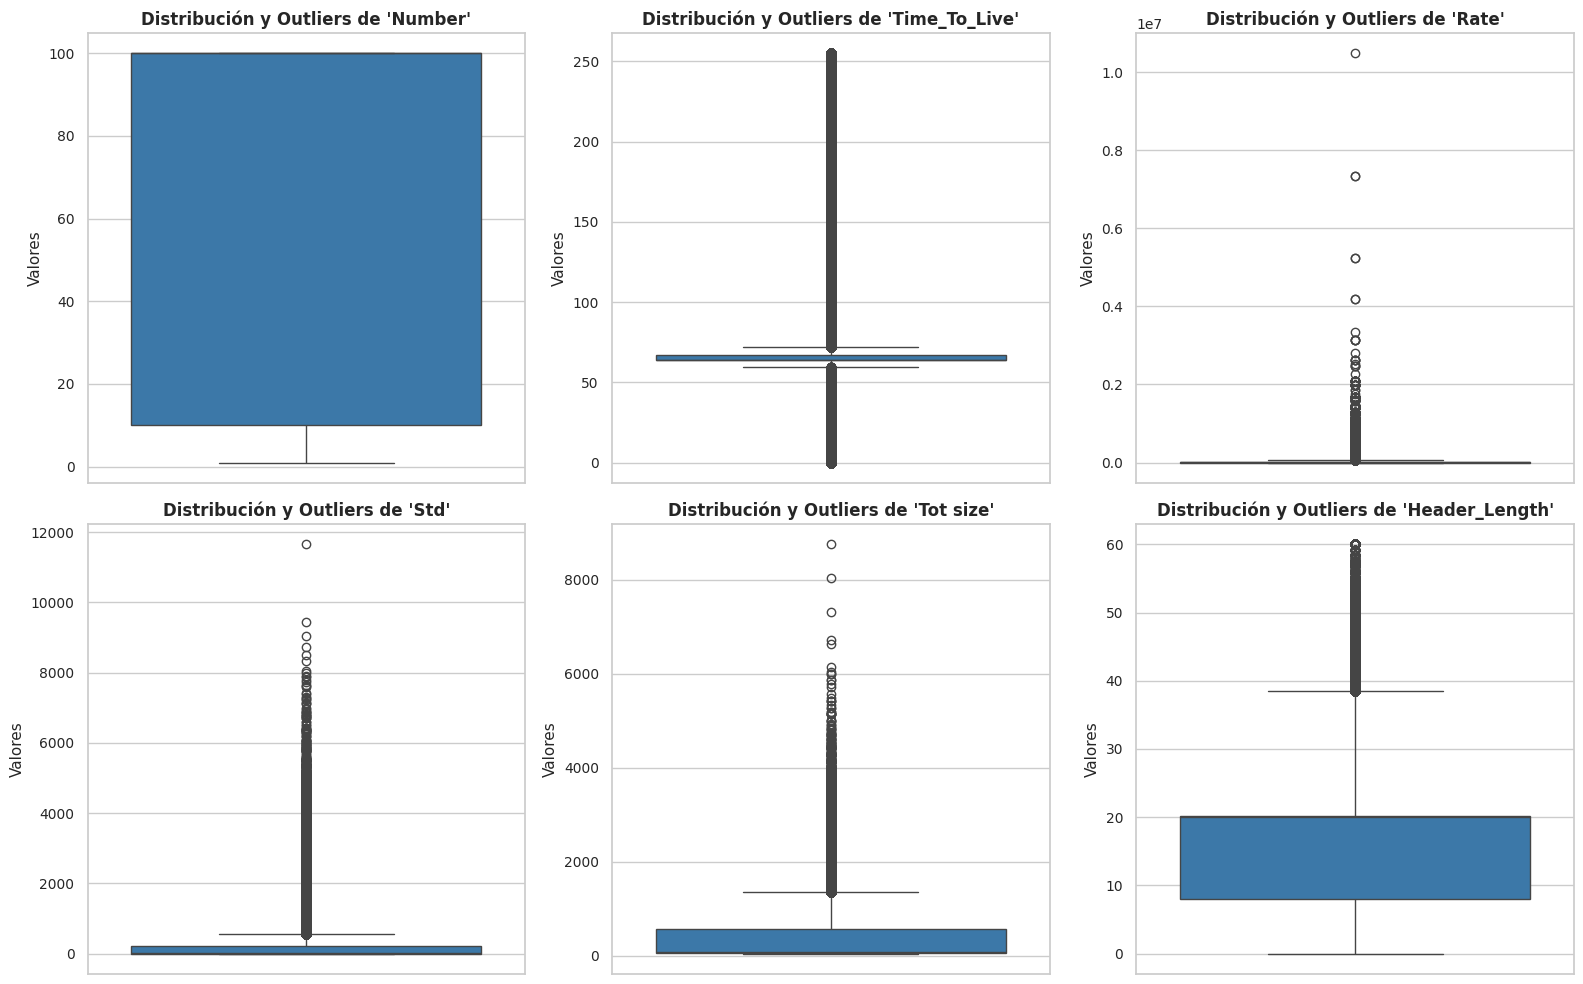

In [6]:
# Selección de características principales para detección de outliers
boxplot_features = ['Number', 'Time_To_Live', 'Rate', 'Std', 'Tot size', 'Header_Length']
boxplot_features = [f for f in boxplot_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(boxplot_features):
    # Limpiar infinitos y nulos para la visualización correcta
    data_clean = df[col].replace([np.inf, -np.inf], np.nan).dropna()
    
    # Usar color distintivo para cada gráfico
    sns.boxplot(y=data_clean, ax=axes[i], color=sns.color_palette("Blues")[4])
    axes[i].set_title(f"Distribución y Outliers de '{col}'", fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Valores")
    axes[i].set_xlabel("")

# Ajustar el layout
plt.tight_layout()
plt.savefig("results/figures/03_boxplots_outliers.png", dpi=300)
plt.show()

## 5. Histogramas de Distribución de Características Clave

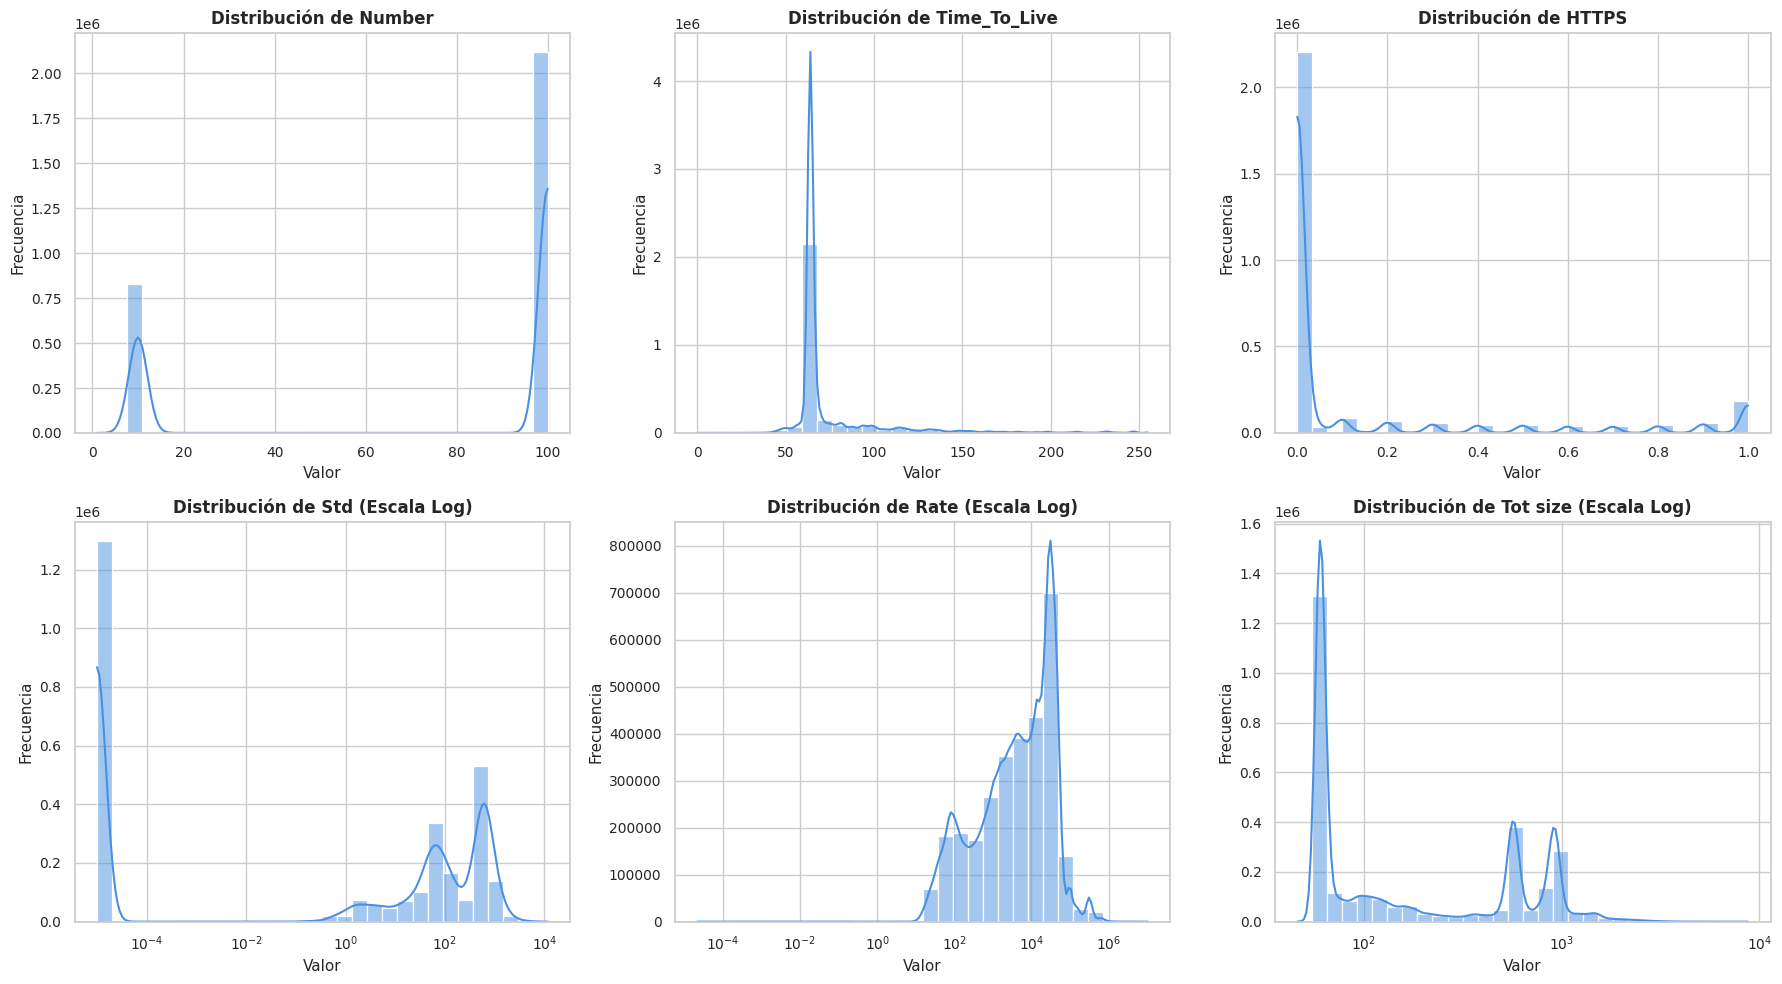

In [9]:
# Características clave solicitadas
hist_features = ['Number', 'Time_To_Live', 'HTTPS', 'Std', 'Rate', 'Tot size']
hist_features = [f for f in hist_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(hist_features):
    data_clean = df[col].replace([np.inf, -np.inf], np.nan).dropna()
    
    # Determinar si aplicamos escala logarítmica debido al sesgo extremo en tráfico IoT
    log_scale = False
    if data_clean.max() > 1000 and col != 'Time_To_Live':
        log_scale = True
        # Evitar log(0) sumando una constante si hay ceros
        if (data_clean <= 0).any():
            data_clean = data_clean + 1e-5
    
    sns.histplot(data_clean, bins=30, ax=axes[i], kde=True, color="#4A90E2", log_scale=log_scale)
    title_str = f"Distribución de {col}" + (" (Escala Log)" if log_scale else "")
    axes[i].set_title(title_str, fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Frecuencia")
    axes[i].set_xlabel("Valor")

plt.tight_layout()
plt.savefig("results/figures/04_histogramas.png", dpi=300)
plt.show()

## 6. Conclusiones y Observaciones Clave para la Tesis

Basado en los gráficos generados:
1. **Distribución de Clases**: A pesar del submuestreo a 2,000 por archivo, el dataset consolidado es muy balanceado en las clases mayoritarias pero aún retiene el desbalance natural de las clases hiper-minoritarias (como `UPLOADING_ATTACK` y `SQLINJECTION`). Esto justifica el uso de **SMOTE** en fases posteriores.
2. **Outliers**: Características como `Rate`, `Number` y `Tot size` exhiben colas sumamente largas y valores atípicos extremos, lo cual es típico de ráfagas de ataques DoS/DDoS. Se requerirá un escalamiento robusto (como `RobustScaler`) en el preprocesamiento.
3. **Correlación**: Existen características altamente correlacionadas (por ejemplo, `Tot sum`, `AVG`, `Max` y `Min`), lo que sugiere multicolinealidad. Deberemos evaluar técnicas de selección o reducción de dimensiones para no sobrecargar los modelos base (XGBoost y LightGBM).